In [156]:
import pandas as pd
from textblob import TextBlob
import pandas as pd
import html
import re 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score,f1_score
from sklearn.metrics import confusion_matrix


In [157]:
df_kaggle = pd.read_excel("10kTrainingData.xlsx",sheet_name="10kAllCol")
df_kaggle.head()

,type,id,subreddit.id,subreddit.name,subreddit.nsfw,created_utc,permalink,body,sentiment,score
0,comment,imlddn9,2qh3l,news,False,1661990368,https://old.reddit.com/r/news/comments/x2cszk/...,Yeah but what the above commenter is saying is...,0.5719,2
1,comment,imld0kj,2qh1i,askreddit,False,1661990206,https://old.reddit.com/r/AskReddit/comments/x2...,I think climate change tends to get some peopl...,0.6634,1
2,comment,imlctri,3l2gt,walkaway,False,1661990120,https://old.reddit.com/r/walkaway/comments/x2m...,Naaa how could anyone be mad at a face like th...,0.2500,1
3,comment,imlctc0,2vvve,pastors,False,1661990114,https://old.reddit.com/r/pastors/comments/x2il...,Can i suggest maybe honing in on LGBTQ?\n\nIt'...,0.9779,2
4,comment,imlcpab,2qh1i,askreddit,False,1661990065,https://old.reddit.com/r/AskReddit/comments/x2...,They need to change laws so it's more worth se...,0.4690,2


In [158]:
df_crawl = pd.read_excel("full_labeled_dataset.xlsx")
df_crawl.head()

,comment,label
0,I’ll believe it when the climate activists wri...,NEGATIVE
1,Yeah we’re all gonna die. Not cause of climate...,NEGATIVE
2,I think climate change is the next big societa...,POSITIVE
3,She could single handely end Climate Change,NEGATIVE
4,"Yeah, at this point carbon capture seems to be...",NEGATIVE


In [159]:
df_eval = pd.read_excel("eval.xlsx")
df_eval.head()

,comment,label
0,1. How can I know you didn't just make this up...,NEGATIVE
1,"It was never a question of ""Will climate chang...",NEGATIVE
2,Climate change is pretty evident. People are s...,NEGATIVE
3,Climate Change is not an On/Off Climate Change...,NEGATIVE
4,We have been fooling ourselves for the last 40...,NEGATIVE


In [160]:
df_kaggle = df_kaggle[["body", "sentiment"]]

df_kaggle = df_kaggle.rename(columns={"body": "comment"})

def score_to_label(score):
    if score > 0.1:
        return "POSITIVE"
    elif score < -0.1:
        return "NEGATIVE"
    else:
        return "NEUTRAL"

df_kaggle["label"] = df_kaggle["sentiment"].apply(score_to_label)
df_kaggle = df_kaggle[["comment", "label"]]
df_kaggle["label"].value_counts()


label
NEGATIVE    4300
POSITIVE    4254
NEUTRAL     1446
Name: count, dtype: int64

In [161]:
df_crawl_train = df_crawl[~df_crawl["comment"].isin(df_eval["comment"])].copy()
overlap = set(df_crawl_train["comment"]).intersection(set(df_eval["comment"]))
print("Overlap:", len(overlap))

Overlap: 0


In [162]:
def clean_text(text):
    text = str(text)
    
    text = html.unescape(text)
    text = text.lower()
    
    text = re.sub(r"http\S+|www\S+", "", text)  # remove URLs
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)  # normalize repeats
    text = re.sub(r"[^a-zA-Z!?']", " ", text)   # keep useful chars
    
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    
    return text

In [163]:
df_train = pd.concat([
    df_crawl_train,
    df_kaggle
]).dropna().reset_index(drop=True)

df_train = df_train.drop_duplicates(subset="comment")

In [164]:
df_train["comment"] = df_train["comment"].apply(clean_text)
df_eval["comment"] = df_eval["comment"].apply(clean_text)

In [165]:
print("Training size:", len(df_train))
print(df_train["label"].value_counts())

print("Eval size:", len(df_eval))
print(df_eval["label"].value_counts())

Training size: 11058
label
NEGATIVE    5136
POSITIVE    4277
NEUTRAL     1645
Name: count, dtype: int64
Eval size: 1000
label
NEGATIVE    400
POSITIVE    400
NEUTRAL     200
Name: count, dtype: int64


Training Model

In [166]:
def get_features(text):
    blob = TextBlob(text)
    return blob.sentiment.polarity, blob.sentiment.subjectivity

df_train[["polarity", "subjectivity"]] = df_train["comment"].apply(
    lambda x: pd.Series(get_features(x))
)
df_eval[["polarity", "subjectivity"]] = df_train["comment"].apply(
    lambda x: pd.Series(get_features(x))
)

In [167]:

preprocessor = ColumnTransformer([
    ("text", TfidfVectorizer(max_features=5000), "comment"),
    ("num", "passthrough", ["polarity", "subjectivity"])
])

model = Pipeline([
    ("pre", preprocessor),
    ("clf", LogisticRegression(max_iter=5000))
])



In [168]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

X = df_train[["comment", "polarity", "subjectivity"]]
y = df_train["label"]

# 🔥 Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 🔹 Accuracy
scores_acc = cross_val_score(
    model,
    X,
    y,
    cv=skf,
    scoring="accuracy",
    n_jobs=-1
)

# 🔹 F1-score
scores_f1 = cross_val_score(
    model,
    X,
    y,
    cv=skf,
    scoring="f1_macro",
    n_jobs=-1
)

print("Stratified CV Accuracy scores:", scores_acc)
print("Mean CV Accuracy:", scores_acc.mean())

print("Stratified CV F1 scores:", scores_f1)
print("Mean CV F1:", scores_f1.mean())

Stratified CV Accuracy scores: [0.69936709 0.68490054 0.67857143 0.68611488 0.71687019]
Mean CV Accuracy: 0.6931648268602737
Stratified CV F1 scores: [0.63835399 0.6217552  0.62623967 0.62723279 0.65480946]
Mean CV F1: 0.6336782211029715


In [169]:
model.fit(df_train[["comment", "polarity", "subjectivity"]],df_train["label"])


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

Evaluation

Random sample accuracy: 0.44


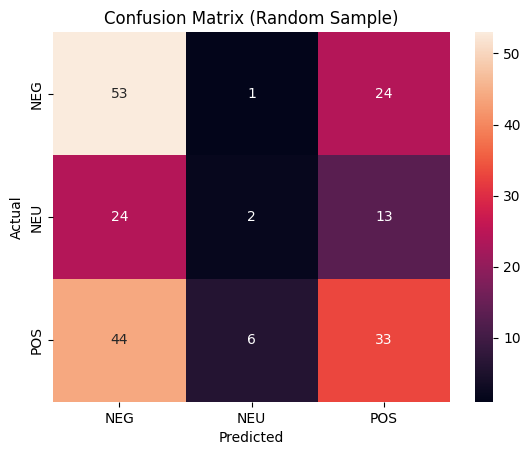

In [170]:

sample = df_eval.sample(n=200, random_state=42)


pred_sample = model.predict(
    sample[["comment", "polarity", "subjectivity"]]
)

acc_sample = accuracy_score(sample["label"], pred_sample)

print("Random sample accuracy:", acc_sample)

cm_sample = confusion_matrix(sample["label"], pred_sample)


plt.figure()
sns.heatmap(
    cm_sample,
    annot=True,
    fmt="d",
    xticklabels=["NEG", "NEU", "POS"],
    yticklabels=["NEG", "NEU", "POS"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Random Sample)")
plt.show()

In [171]:
import time


start = time.time()

pred = model.predict(
    df_eval[["comment", "polarity", "subjectivity"]]
)


end = time.time()

time_taken = end - start
records_per_sec = len(df_eval) / time_taken

print("Time taken:", time_taken)
print("Records per second:", records_per_sec)

Time taken: 0.059999942779541016
Records per second: 16666.682561253765


Question 5 Ensemble Method + Stacking

To improve the performance of the sentiment classification system, several enhancement were explored beyond the baseline model
1. Experimentation on max_features
2. Enhancement beyond unigram to be able to regonise 2 words such as "not good"
3. Ensemble Classification using stacking.


In [172]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import StackingClassifier

In [173]:
X_train = df_train[["comment", "polarity", "subjectivity"]]
y_train = df_train["label"]

X_eval = df_eval[["comment", "polarity", "subjectivity"]]
y_eval = df_eval["label"]

In [174]:
def evaluate_model(model):
    model.fit(X_train, y_train)
    
    pred = model.predict(X_eval)
    
    return pred

Baseline model, max_feature experiment

In [175]:
pre = ColumnTransformer([
    ("text", TfidfVectorizer(max_features=5000, ngram_range=(1,1)), "comment"),
    ("num", "passthrough", ["polarity", "subjectivity"])
])
        
base_model = Pipeline([
    ("pre", pre),
    ("clf", LogisticRegression(max_iter=5000))
])


model_lr5k_pred = evaluate_model(base_model)
print("\n5k Baseline Classification Report:")
print(classification_report(y_eval, model_lr5k_pred))


5k Baseline Classification Report:
              precision    recall  f1-score   support

    NEGATIVE       0.48      0.71      0.57       400
     NEUTRAL       0.17      0.04      0.06       200
    POSITIVE       0.48      0.45      0.47       400

    accuracy                           0.47      1000
   macro avg       0.38      0.40      0.37      1000
weighted avg       0.42      0.47      0.43      1000



In [176]:
def experiment_max_features(start=1000, end=30000, step=1000):

    
    results = []
    
    for mf in range(start, end + 1, step):
        pre = ColumnTransformer([
            ("text", TfidfVectorizer(max_features=mf, ngram_range=(1,1)), "comment"),
            ("num", "passthrough", ["polarity", "subjectivity"])
        ])
        
        model = Pipeline([
            ("pre", pre),
            ("clf", LogisticRegression(max_iter=5000))
        ])
        
        # train
        model.fit(X_train, y_train)
        
        # predict
        pred = model.predict(X_eval)
        
        # metrics
        acc = accuracy_score(y_eval, pred)
        f1 = f1_score(y_eval, pred, average="macro")
        
        print(f"max_features={mf} → Acc: {acc:.4f}, F1: {f1:.4f}")
        
        results.append({
            "max_features": mf,
            "Accuracy": acc,
            "F1": f1
        })
    
    df_results = pd.DataFrame(results)
    
    return df_results

In [177]:
df_features = experiment_max_features(1000, 30000, 1000)
print(df_features)

max_features=1000 → Acc: 0.4550, F1: 0.3542
max_features=2000 → Acc: 0.4650, F1: 0.3624
max_features=3000 → Acc: 0.4670, F1: 0.3614
max_features=4000 → Acc: 0.4740, F1: 0.3686
max_features=5000 → Acc: 0.4710, F1: 0.3665
max_features=6000 → Acc: 0.4670, F1: 0.3610
max_features=7000 → Acc: 0.4690, F1: 0.3600
max_features=8000 → Acc: 0.4720, F1: 0.3644
max_features=9000 → Acc: 0.4720, F1: 0.3646
max_features=10000 → Acc: 0.4760, F1: 0.3676
max_features=11000 → Acc: 0.4790, F1: 0.3700
max_features=12000 → Acc: 0.4770, F1: 0.3683
max_features=13000 → Acc: 0.4760, F1: 0.3677
max_features=14000 → Acc: 0.4750, F1: 0.3666
max_features=15000 → Acc: 0.4750, F1: 0.3668
max_features=16000 → Acc: 0.4730, F1: 0.3653
max_features=17000 → Acc: 0.4760, F1: 0.3680
max_features=18000 → Acc: 0.4730, F1: 0.3656
max_features=19000 → Acc: 0.4700, F1: 0.3630
max_features=20000 → Acc: 0.4710, F1: 0.3637
max_features=21000 → Acc: 0.4720, F1: 0.3646
max_features=22000 → Acc: 0.4760, F1: 0.3681
max_features=23000 

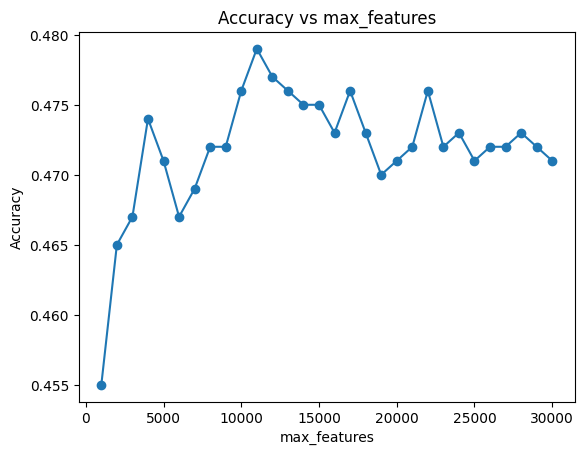

In [178]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df_features["max_features"], df_features["Accuracy"], marker='o')
plt.title("Accuracy vs max_features")
plt.xlabel("max_features")
plt.ylabel("Accuracy")
plt.show()

Final Max_feature value = 15000

In [179]:
pre = ColumnTransformer([
    ("text", TfidfVectorizer(max_features=11000, ngram_range=(1,1)), "comment"),
    ("num", "passthrough", ["polarity", "subjectivity"])
])
        
model = Pipeline([
    ("pre", pre),
    ("clf", LogisticRegression(max_iter=5000))
])



model_lr11k_pred = evaluate_model(model)
print("\n11k Baseline Classification Report:")
print(classification_report(y_eval, model_lr11k_pred))


11k Baseline Classification Report:
              precision    recall  f1-score   support

    NEGATIVE       0.49      0.72      0.59       400
     NEUTRAL       0.16      0.03      0.05       200
    POSITIVE       0.49      0.46      0.47       400

    accuracy                           0.48      1000
   macro avg       0.38      0.40      0.37      1000
weighted avg       0.43      0.48      0.43      1000



ngram model

In [180]:
pre_ngram = ColumnTransformer([
    ("text", TfidfVectorizer(max_features=11000, ngram_range=(1,2)), "comment"),
    ("num", "passthrough", ["polarity", "subjectivity"])
])

model_lr = Pipeline([
    ("pre", pre_ngram),
    ("clf", LogisticRegression(max_iter=5000))
])


model_bigram_pred = evaluate_model(model_lr)
print("\nBiGram Classification Report:")
print(classification_report(y_eval, model_bigram_pred))


BiGram Classification Report:
              precision    recall  f1-score   support

    NEGATIVE       0.49      0.73      0.58       400
     NEUTRAL       0.21      0.04      0.06       200
    POSITIVE       0.49      0.45      0.47       400

    accuracy                           0.48      1000
   macro avg       0.40      0.41      0.37      1000
weighted avg       0.43      0.48      0.43      1000



In [181]:
# Naive Bayes Model
model_nb = Pipeline([
    ("pre", ColumnTransformer([
        ("text", TfidfVectorizer(max_features=15000), "comment")
    ])),
    ("clf", MultinomialNB())
])

# SVM Model
model_svm = Pipeline([
    ("pre", preprocessor),
    ("clf", LinearSVC())
])

In [182]:
stack_all = StackingClassifier(
    estimators=[
        ("lr", model_lr),
        ("nb", model_nb),
        ("svm", model_svm)
    ],
    final_estimator=LogisticRegression(),
    n_jobs=-1
)

model_stackall_pred = evaluate_model(stack_all)
print("\nStacking (All) Classification Report:")
print(classification_report(y_eval, model_stackall_pred))



Stacking (All) Classification Report:
              precision    recall  f1-score   support

    NEGATIVE       0.49      0.72      0.58       400
     NEUTRAL       0.19      0.04      0.06       200
    POSITIVE       0.49      0.46      0.48       400

    accuracy                           0.48      1000
   macro avg       0.39      0.41      0.37      1000
weighted avg       0.43      0.48      0.43      1000



In [183]:
stack_lr_nb = StackingClassifier(
    estimators=[("lr", model_lr), ("nb", model_nb)],
    final_estimator=LogisticRegression(),
    n_jobs=-1
)

stack_lr_svm = StackingClassifier(
    estimators=[("lr", model_lr), ("svm", model_svm)],
    final_estimator=LogisticRegression(),
    n_jobs=-1
)

stack_nb_svm = StackingClassifier(
    estimators=[("nb", model_nb), ("svm", model_svm)],
    final_estimator=LogisticRegression(),
    n_jobs=-1
)
model_stack_lr_nb_pred = evaluate_model(stack_lr_nb)
print("\nLR + NB Classification Report:")
print(classification_report(y_eval, model_stack_lr_nb_pred))

model_lr_svm_pred = evaluate_model(stack_lr_svm)
print("\nLR + SVM Classification Report:")
print(classification_report(y_eval, model_lr_svm_pred))

model_nb_svm_pred = evaluate_model(stack_nb_svm)
print("\nNB + SVM Classification Report:")
print(classification_report(y_eval, model_nb_svm_pred))


LR + NB Classification Report:
              precision    recall  f1-score   support

    NEGATIVE       0.49      0.74      0.59       400
     NEUTRAL       0.19      0.04      0.06       200
    POSITIVE       0.51      0.45      0.48       400

    accuracy                           0.48      1000
   macro avg       0.40      0.41      0.38      1000
weighted avg       0.44      0.48      0.44      1000


LR + SVM Classification Report:
              precision    recall  f1-score   support

    NEGATIVE       0.49      0.71      0.58       400
     NEUTRAL       0.18      0.03      0.05       200
    POSITIVE       0.50      0.48      0.49       400

    accuracy                           0.48      1000
   macro avg       0.39      0.41      0.37      1000
weighted avg       0.43      0.48      0.44      1000


NB + SVM Classification Report:
              precision    recall  f1-score   support

    NEGATIVE       0.49      0.70      0.58       400
     NEUTRAL       0.15      0.

For Comparison

In [184]:
print("\n5k Baseline Classification Report:")
print(classification_report(y_eval, model_lr5k_pred,digits=3))

print("\n15k Baseline Classification Report:")
print(classification_report(y_eval, model_lr11k_pred,digits=3))

print("\nBiGram Classification Report:")
print(classification_report(y_eval, model_bigram_pred,digits=3))

print("\nLR + NB Classification Report:")
print(classification_report(y_eval, model_stack_lr_nb_pred,digits=3))

print("\nLR + SVM Classification Report:")
print(classification_report(y_eval, model_lr_svm_pred,digits=3))

print("\nNB + SVM Classification Report:")
print(classification_report(y_eval, model_nb_svm_pred,digits=3))

print("\nStacking (All) Classification Report:")
print(classification_report(y_eval, model_stackall_pred,digits=3))



5k Baseline Classification Report:
              precision    recall  f1-score   support

    NEGATIVE      0.483     0.710     0.575       400
     NEUTRAL      0.175     0.035     0.058       200
    POSITIVE      0.484     0.450     0.466       400

    accuracy                          0.471      1000
   macro avg      0.381     0.398     0.367      1000
weighted avg      0.422     0.471     0.428      1000


15k Baseline Classification Report:
              precision    recall  f1-score   support

    NEGATIVE      0.492     0.725     0.586       400
     NEUTRAL      0.162     0.030     0.051       200
    POSITIVE      0.491     0.458     0.473       400

    accuracy                          0.479      1000
   macro avg      0.381     0.404     0.370      1000
weighted avg      0.425     0.479     0.434      1000


BiGram Classification Report:
              precision    recall  f1-score   support

    NEGATIVE      0.485     0.735     0.584       400
     NEUTRAL      0.212  

Additional Implementation: Using Transformer (BERT) 

In [185]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments
from datasets import Dataset

In [186]:
label_map = {
    "NEGATIVE": 0,
    "NEUTRAL": 1,
    "POSITIVE": 2
}

In [187]:
df_train["label_id"] = df_train["label"].map(label_map)
df_eval["label_id"] = df_eval["label"].map(label_map)

In [188]:
train_dataset = Dataset.from_pandas(df_train[["comment", "label_id"]])
eval_dataset = Dataset.from_pandas(df_eval[["comment", "label_id"]])

In [189]:
train_dataset = train_dataset.rename_column("label_id", "label")
eval_dataset = eval_dataset.rename_column("label_id", "label")

In [190]:
# load model
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [191]:
def tokenize(example):
    return tokenizer(
        example["comment"],
        truncation=True,
        padding="max_length",
        max_length=128   # 🔥 fast + enough for sentiment
    )

train_dataset = train_dataset.map(tokenize, batched=True)
eval_dataset = eval_dataset.map(tokenize, batched=True)

Map: 100%|██████████| 1000/1000 [00:00<00:00, 8574.22 examples/s]


In [192]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 12486.02it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [193]:
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.5.1+cu121
12.1
True
NVIDIA GeForce RTX 4060 Laptop GPU


In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    per_device_train_batch_size=16,   
    per_device_eval_batch_size=16,
    eval_strategy="no",
    save_strategy="no",
    logging_steps=50,
    fp16=True                       
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset
)

trainer.train()

Step,Training Loss
50,0.985889
100,0.901136
150,0.841733
200,0.819861
250,0.788113
300,0.705405
350,0.754425
400,0.729177
450,0.694705
500,0.723850


TrainOutput(global_step=1384, training_loss=0.6247116244597242, metrics={'train_runtime': 84.9957, 'train_samples_per_second': 260.202, 'train_steps_per_second': 16.283, 'total_flos': 732425308701696.0, 'train_loss': 0.6247116244597242, 'epoch': 2.0})

In [197]:
predictions = trainer.predict(eval_dataset)

preds = np.argmax(predictions.predictions, axis=1)

id_to_label = {
    0: "NEGATIVE",
    1: "NEUTRAL",
    2: "POSITIVE"
}

pred_labels = [id_to_label[p] for p in preds]

true_labels = df_eval["label"].tolist()
print("BERT Accuracy:", accuracy_score(true_labels, pred_labels))
print("BERT F1:", f1_score(true_labels, pred_labels, average="macro"))

print("\nBERT Classification Report:")
print(classification_report(true_labels, pred_labels, digits=3))

BERT Accuracy: 0.52
BERT F1: 0.4069417698072509

BERT Classification Report:
              precision    recall  f1-score   support

    NEGATIVE      0.560     0.680     0.614       400
     NEUTRAL      0.128     0.030     0.049       200
    POSITIVE      0.518     0.605     0.558       400

    accuracy                          0.520      1000
   macro avg      0.402     0.438     0.407      1000
weighted avg      0.457     0.520     0.479      1000

